# 19 — Aporte del clima y sensibilidad de las curvas de GAITANA

Se conserva el algoritmo de memoria larga, los grupos H1–H2/H3–H5, las dos rutas, parámetros y cortes mensuales. Se comparan cuatro alternativas: **Sin_clima**, **Clima_basico** (temperatura/humedad/radiación semanales y diarias ya existentes, ahora actualizadas), **Clima_ampliado** (añade lluvia y señales de 14/28 días de 18), y **Curva_Gaitana_clima** (mismo clima ampliado, pero referencia teórica atribuida a GAITANA en 01).

La tercera comparación aísla el bloque ampliado; la cuarta cambia conjuntamente cobertura y referencia local, que se diagnostican explícitamente. No se afirma origen certificado de los pilotos. Las curvas compartidas no se eliminan ni se sustituyen silenciosamente.

El candidato para propagar al diario se fija por menor WAPE de noviembre–diciembre de 2025, usando objetivos terminados antes de 2026 y entrenamiento anterior a cada corte. Después se evalúan todos los candidatos en los mismos casos de 2026 y se conserva esa elección aunque otro tenga menor error retrospectivo. Esta validación es temporal, pero el proyecto ya examinó esos periodos: sigue siendo desarrollo, no test prospectivo intacto. El ingeniero sólo sirve de referencia externa.

Train y test se registran por ajuste; no se mezclan errores de entrenamiento de meses superpuestos en una métrica global.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits

ROOT = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"Datos_analiticos_proyecto").is_dir())
SALIDA = ROOT/"Datos_analiticos_proyecto"

KEY=['finca','producto','color','variedad']
DESTINO=SALIDA/'modelo_con_proyecciones_teoricas'
integrados=pd.read_parquet(DESTINO/'base_analitica_proyecciones.parquet')
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
categoricas=['producto','color','variedad']
temporales=['horizonte','semana_seno','semana_coseno']
memoria=['produccion_lag1','produccion_lag2','produccion_lag3','media_4','media_8','desv_4','tendencia_4_8','cambio_reciente','produccion_52']
climaticas=[v+s for v in ['temperatura_semana','humedad_semana','radiacion_semana'] for s in ['_lag1','_media4']]
agronomicas=[]
X_columnas=categoricas+temporales+memoria+climaticas
X_teoria=X_columnas+['teoria_modelo','antiguedad_curva','desviacion_reciente_teoria']
X_historia=X_teoria+['teoria_previa_1','teoria_previa_2','revision_teoria']
assert 'y' not in X_historia
assert not integrados.duplicated(KEY+['origen','horizonte']).any()

from IPython.display import display
AUD=ROOT/'Notebooks/Proyecciones Teoricas Propias/resultados_todos_los_anios/auditoria_calidad'


In [2]:
CORTES = [pd.Timestamp("2025-07-07"),pd.Timestamp("2026-01-05"),pd.Timestamp("2026-05-04")]
SEMANAS_EVALUACION = 8

def crear_modelo(nombre,columnas):
    numericas = [c for c in columnas if c not in categoricas]
    numerico = make_pipeline(SimpleImputer(strategy="median",add_indicator=True,keep_empty_features=True),
                             StandardScaler()) if nombre.startswith("Ridge") else SimpleImputer(
                                 strategy="median",add_indicator=True,keep_empty_features=True)
    preparar = ColumnTransformer([
        ("categorias",OneHotEncoder(handle_unknown="ignore",sparse_output=False,dtype=np.float32),categoricas),
        ("numericas",numerico,numericas)])
    estimador = Ridge(alpha=100.0) if nombre.startswith("Ridge") else HistGradientBoostingRegressor(
        learning_rate=.08,max_iter=80,max_leaf_nodes=15,min_samples_leaf=40,
        l2_regularization=1.0,early_stopping=False,random_state=42)
    return make_pipeline(preparar,estimador)
print("Sesgo positivo = sobreestimación; negativo = subestimación (predicción menos real).")
print("±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.")


Sesgo positivo = sobreestimación; negativo = subestimación (predicción menos real).
±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.


In [3]:
llave=KEY+['origen','semana_objetivo','horizonte']
actual=pd.read_parquet(DESTINO/'comparacion_features_diarias_2026.parquet')
f=pd.read_parquet(SALIDA/'modelo_diario/features_diarias.parquet')
diarias=[c for c in f if c not in KEY+['fecha']]
integrados=integrados.merge(f.rename(columns={'fecha':'origen'}),on=KEY+['origen'],how='left',validate='many_to_one')
base=pd.read_parquet(DESTINO/'produccion_clima_semanal.parquet')
def memoria_larga(base):
    calendario=pd.DataFrame({'origen':pd.date_range(base.semana_inicio.min(),base.semana_inicio.max()+pd.Timedelta(weeks=1),freq='W-MON')})
    z=base[KEY].drop_duplicates().merge(calendario,how='cross').merge(base[KEY+['semana_inicio','tallos_reales']].rename(columns={'semana_inicio':'origen'}),on=KEY+['origen'],how='left',validate='one_to_one').sort_values(KEY+['origen'])
    g=z.groupby(KEY).tallos_reales
    z['media_12']=g.transform(lambda s:s.shift(1).rolling(12,min_periods=4).mean())
    for v in [8,12]:z[f'desv_{v}']=g.transform(lambda s:s.shift(1).rolling(v,min_periods=4).std())
    for v in [4,8,12]:z[f'reportes_{v}']=g.transform(lambda s:s.shift(1).rolling(v,min_periods=1).count())
    return z.drop(columns='tallos_reales')
extra=memoria_larga(base)
extra_cols=[c for c in extra if c not in KEY+['origen']]
integrados=integrados.merge(extra,on=KEY+['origen'],how='left',validate='many_to_one')
integrados['tendencia_4_12']=integrados.media_4-integrados.media_12
extra_cols+=['tendencia_4_12']
alterada=base.copy(); corte_prueba=pd.Timestamp('2025-01-06')
alterada.loc[alterada.semana_inicio.ge(corte_prueba),'tallos_reales']+=1000000
prueba=memoria_larga(alterada)
pd.testing.assert_frame_equal(extra.loc[extra.origen.le(corte_prueba)].reset_index(drop=True),prueba.loc[prueba.origen.le(corte_prueba)].reset_index(drop=True))
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
datos['grupo_h']=np.where(datos.horizonte.le(2),'H1_H2','H3_H5')
elegibles=datos.merge(actual[llave],on=llave,how='inner',validate='one_to_one')
assert len(elegibles)==len(actual)
Xbase=X_columnas+diarias
Xteoria=X_teoria+diarias
historia=['teoria_previa_1','teoria_previa_2','revision_teoria']
display(datos[extra_cols].isna().mean().mul(100).to_frame('faltantes_pct'))
print('Prueba temporal superada: alterar producción futura no cambia las variables disponibles al origen.')


,faltantes_pct
media_12,0.0
desv_8,0.0
desv_12,0.0
reportes_4,0.0
reportes_8,0.0
reportes_12,0.0
tendencia_4_12,0.0


Prueba temporal superada: alterar producción futura no cambia las variables disponibles al origen.


In [4]:
OUT=SALIDA/'revision_clima_finca'
fclima=pd.read_parquet(OUT/'features_clima_ampliado.parquet')
extra_clima=[c for c in fclima if c not in ['finca','origen']]
datos=datos.merge(fclima,on=['finca','origen'],how='left',validate='many_to_one')
local=pd.read_parquet(OUT/'proyecciones_gaitana_inferida.parquet').rename(columns={'semana_proyeccion':'semana_objetivo'})
aux=['union_'+c for c in KEY]
datos=datos.merge(local,on=['plano','semana_objetivo']+aux,how='left',validate='many_to_one')
assert datos.finca.eq('GAITANA').all()
datos['curva_local_completa']=datos.teoria_local.notna()&datos.sin_cobertura_local.eq(0)
print('Cobertura de curva completa por año; mismo universo admisible:')
display(datos.groupby(datos.origen.dt.year)[['curva_completa','curva_local_completa']].mean())
elegibles=datos.merge(actual[llave],on=llave,how='inner',validate='one_to_one')
assert len(elegibles)==len(actual)
clima_basico=climaticas+[c for c in diarias if any(v in c for v in ['temperatura','humedad','radiacion'])]
ETAPAS=['Sin_clima','Clima_basico','Clima_ampliado','Curva_Gaitana_clima']
ultimos_train=[]
ultimo_corte=elegibles.groupby(elegibles.origen.dt.to_period('M')).origen.min().max()
controles=[]
def metricas(y,p):
    e=np.asarray(y)-np.asarray(p)
    return {'n':len(e),'MAE':np.abs(e).mean(),'RMSE':np.sqrt(np.mean(e**2)),'WAPE':np.abs(e).sum()/np.asarray(y).sum(),'sesgo':-e.mean(),'sesgo_pct':-100*e.sum()/np.asarray(y).sum()}
def pronosticar(train,test,etapa,corte,fase):
    train=train.copy();test=test.copy()
    if etapa=='Curva_Gaitana_clima':
        for d in [train,test]:
            d['curva_completa']=d.curva_local_completa
            d['teoria_modelo']=d.teoria_local.where(d.curva_local_completa)
            d['desviacion_reciente_teoria']=d.media_4-d.teoria_modelo
    xb=Xbase+extra_cols;xt=Xteoria+extra_cols
    if etapa=='Sin_clima':xb=[c for c in xb if c not in clima_basico];xt=[c for c in xt if c not in clima_basico]
    if etapa in ['Clima_ampliado','Curva_Gaitana_clima']:xb+=extra_clima;xt+=extra_clima
    pred=pd.Series(index=test.index,dtype=float);p_train=pd.Series(index=train.index,dtype=float)
    for grupo,te in test.groupby('grupo_h'):
        tr=train.loc[train.grupo_h.eq(grupo)]
        with threadpool_limits(limits=2):
            mod=crear_modelo('Boosting',xb);mod.fit(tr[xb],tr.y-tr.media_4)
            pred.loc[te.index]=np.maximum(0,te.media_4+mod.predict(te[xb]))
            p_train.loc[tr.index]=np.maximum(0,tr.media_4+mod.predict(tr[xb]))
            tc=tr.loc[tr.curva_completa];ec=te.loc[te.curva_completa]
            if len(tc)>=40:
                mod=crear_modelo('Boosting',xt);mod.fit(tc[xt],tc.y-tc.teoria_modelo)
                p_train.loc[tc.index]=np.maximum(0,tc.teoria_modelo+mod.predict(tc[xt]))
                if len(ec):pred.loc[ec.index]=np.maximum(0,ec.teoria_modelo+mod.predict(ec[xt]))
    assert pred.notna().all() and p_train.notna().all()
    for split,d,p in [('train',train,p_train),('test',test,pred)]:
        controles.append({'fase':fase,'corte':corte,'modelo':etapa,'split':split,'origen_min':d.origen.min(),'origen_max':d.origen.max(),'objetivo_max':d.semana_objetivo.max(),'casos_teoria_completa':int(d.curva_completa.sum())}|metricas(d.y,p))
    if fase=='evaluacion_2026' and corte==ultimo_corte:
        z=train.loc[train.horizonte.eq(1),llave+['y']].copy()
        z['prediccion_train']=p_train.loc[z.index];z['modelo']=etapa;z['corte']=corte
        ultimos_train.append(z)
    return pred
valid=datos.loc[datos.origen.ge('2025-11-03')&(datos.semana_objetivo+pd.Timedelta(days=7)).le(pd.Timestamp('2026-01-01'))].copy()
val=[]
for mes,te in valid.groupby(valid.origen.dt.to_period('M')):
    corte=te.origen.min();tr=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte)]
    z=te[llave+['y']].copy()
    for etapa in ETAPAS:z[etapa]=pronosticar(tr,te,etapa,corte,'validacion_pre2026');print('Validación',mes,etapa,flush=True)
    val.append(z)
val=pd.concat(val,ignore_index=True)
tabla_validacion=pd.DataFrame([{'modelo':e}|metricas(val.y,val[e]) for e in ETAPAS]).sort_values(['WAPE','modelo'])
elegido=tabla_validacion.iloc[0].modelo
display(tabla_validacion);print('Candidato fijado antes de evaluar 2026:',elegido)
val.to_parquet(OUT/'validacion_clima_pre2026.parquet',index=False)


Cobertura de curva completa por año; mismo universo admisible:


,curva_completa,curva_local_completa
origen,,
2021,0.331176,0.237121
2022,0.254123,0.211531
2023,0.329214,0.205226
2024,0.437326,0.109290
2025,0.244850,0.083924
2026,0.085689,0.037916


Validación 2025-11 Sin_clima


Validación 2025-11 Clima_basico


Validación 2025-11 Clima_ampliado


...

Validación 2025-12 Clima_basico


Validación 2025-12 Clima_ampliado


Validación 2025-12 Curva_Gaitana_clima


,modelo,n,MAE,RMSE,WAPE,sesgo,sesgo_pct
0,Sin_clima,3548,2054.063520,3488.375355,0.217896,137.915904,1.463021
1,Clima_basico,3548,2070.299272,3545.985805,0.219619,216.191715,2.293376
2,Clima_ampliado,3548,2090.091964,3566.866025,0.221718,323.518164,3.431902
3,Curva_Gaitana_clima,3548,2201.031684,3795.529904,0.233487,426.564980,4.525029


Candidato fijado antes de evaluar 2026: Sin_clima


In [5]:
salidas=[]
for mes,te in elegibles.groupby(elegibles.origen.dt.to_period('M')):
    corte=te.origen.min();tr=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte)]
    assert tr.semana_objetivo.max()+pd.Timedelta(days=7)<=corte
    z=te[llave+['y','curva_completa','curva_local_completa','teoria_modelo','teoria_local']].copy()
    for etapa in ETAPAS:z[etapa]=pronosticar(tr,te,etapa,corte,'evaluacion_2026');print(mes,etapa,flush=True)
    z['Seleccion_pre2026']=z[elegido];z['modelo_seleccionado']=elegido;z['corte']=corte
    salidas.append(z)
pred=pd.concat(salidas,ignore_index=True)
pred=pred.merge(actual[llave+['ingeniero','grupo_comparacion']],on=llave,validate='one_to_one')
basico=pd.read_parquet(DESTINO/'experimentos_horizontes_2026.parquet')
ver=pred.merge(basico[llave+['Memoria_larga']],on=llave,validate='one_to_one')
assert np.allclose(ver.Clima_basico,ver.Memoria_larga,rtol=1e-9,atol=1e-6)
antes=pd.read_parquet(OUT/'predicciones_antes_clima.parquet')
pred=pred.merge(antes[llave+['Memoria_larga']].rename(columns={'Memoria_larga':'Antes_actualizar_clima'}),on=llave,validate='one_to_one')
pred.to_parquet(OUT/'comparacion_clima_curvas_2026.parquet',index=False)
pd.concat(ultimos_train,ignore_index=True).to_parquet(OUT/'predicciones_train_h1_ultimo_ajuste.parquet',index=False)
pd.DataFrame(controles).to_parquet(OUT/'train_test_clima_por_corte.parquet',index=False)
print('Clima básico reproduce exactamente memoria larga actualizada. Fuentes y caso comparables preservados.')


2026-01 Sin_clima


2026-01 Clima_basico


2026-01 Clima_ampliado


2026-01 Curva_Gaitana_clima


2026-02 Sin_clima


...

2026-08 Sin_clima


2026-08 Clima_basico


2026-08 Clima_ampliado


2026-08 Curva_Gaitana_clima


Clima básico reproduce exactamente memoria larga actualizada. Fuentes y caso comparables preservados.


## Resultados en los mismos casos y qué cambia al añadir clima

La comparación principal conserva las mismas llaves comerciales, orígenes y objetivos del ingeniero. Las contribuciones se miden emparejando errores; no se interpreta el ranking de variables como un efecto agronómico. Los intervalos remuestrean bloques de semana objetivo; son exploratorios y no corrigen toda dependencia temporal ni decisiones anteriores de desarrollo.

Además del WAPE, se informa cuánto cambia el estimado al introducir clima, con signo y magnitud absoluta. Mover la predicción no significa mejorarla: ambas cantidades se muestran por separado.

El sesgo porcentual es 100 × suma(predicción − real) / suma(real): positivo indica sobreestimación y negativo subestimación. Se reporta junto al WAPE; un sesgo cercano a cero puede ocultar errores de signos opuestos. La columna `sesgo` expresa el error medio firmado en tallos con esta misma convención; algunos cuadernos históricos usaban el signo contrario.

,n,MAE,RMSE,WAPE,sesgo,sesgo_pct
modelo,,,,,,
Antes_actualizar_clima,15838.0,2512.654861,4506.781338,0.195869,-453.710858,-3.536822
Clima_ampliado,15838.0,2496.431029,4453.852579,0.194605,-379.833829,-2.960926
Clima_basico,15838.0,2510.254451,4502.662825,0.195682,-459.261033,-3.580087
Curva_Gaitana_clima,15838.0,2515.813867,4505.622013,0.196116,-354.264973,-2.761609
Seleccion_pre2026,15838.0,2496.165835,4439.960058,0.194584,-310.922527,-2.423741
Sin_clima,15838.0,2496.165835,4439.960058,0.194584,-310.922527,-2.423741
ingeniero,15838.0,2531.724839,4403.875315,0.197356,-1250.135497,-9.745207


n          MAE         RMSE      WAPE  \
horizonte modelo                                                               
1.0       Antes_actualizar_clima  3413.0  1980.525381  3522.158918  0.156782   
          Clima_ampliado          3413.0  1978.258579  3479.759657  0.156603   
          Clima_basico            3413.0  1975.061618  3510.873838  0.156350   
          Curva_Gaitana_clima     3413.0  1975.691377  3477.367392  0.156399   
          Seleccion_pre2026       3413.0  1978.157494  3536.185225  0.156595   
          Sin_clima               3413.0  1978.157494  3536.185225  0.156595   
          ingeniero               3413.0  2158.891005  3727.656625  0.170902   
2.0       Antes_actualizar_clima  3289.0  2246.210916  4020.925019  0.175569   
          Clima_ampliado          3289.0  2244.573444  3997.799007  0.175441   
          Clima_basico            3289.0  2247.414722  4016.950062  0.175663   
          Curva_Gaitana_clima     3289.0  2253.924531  4012.637822  0.176172   
          Seleccion_pre2026       3289.0  2222.803988  3978.399123  0.173739   
          Sin_clima               3289.0  2222.803988  3978.399123  0.173739   
          ingeniero               3289.0  2467.040438  4271.206690  0.192829   
3.0       Antes_actualizar_clima  3166.0  2611.903890  4679.461369  0.203887   
          Clima_ampliado          3166.0  2574.825503  4589.529583  0.200992   
          Clima_basico            3166.0  2607.315125  4676.979652  0.203529   
          Curva_Gaitana_clima     3166.0  2590.404803  4637.410866  0.202209   
          Seleccion_pre2026       3166.0  2611.504548  4644.514210  0.203856   
          Sin_clima               3166.0  2611.504548  4644.514210  0.203856   
          ingeniero               3166.0  2602.472205  4469.143353  0.203151   
4.0       Antes_actualizar_clima  3045.0  2866.826385  5075.071249  0.221372   
          Clima_ampliado          3045.0  2833.688844  5011.981737  0.218813   
          Clima_basico            3045.0  2865.048281  5072.545518  0.221234   
          Curva_Gaitana_clima     3045.0  2864.891169  5083.777514  0.221222   
          Seleccion_pre2026       3045.0  2843.244081  4986.924434  0.219551   
          Sin_clima               3045.0  2843.244081  4986.924434  0.219551   
          ingeniero               3045.0  2707.974384  4686.461443  0.209105   
5.0       Antes_actualizar_clima  2925.0  2957.036856  5177.710024  0.227686   
          Clima_ampliado          2925.0  2948.306319  5134.228325  0.227014   
          Clima_basico            2925.0  2955.878964  5175.723805  0.227597   
          Curva_Gaitana_clima     2925.0  2996.393971  5246.406252  0.230717   
          Seleccion_pre2026       2925.0  2921.818471  5011.447053  0.224975   
          Sin_clima               2925.0  2921.818471  5011.447053  0.224975   
          ingeniero               2925.0  2779.438632  4878.863188  0.214012   

                                        sesgo  sesgo_pct  
horizonte modelo                                          
1.0       Antes_actualizar_clima  -216.367413  -1.712806  
          Clima_ampliado           -69.914370  -0.553455  
          Clima_basico            -213.900247  -1.693275  
          Curva_Gaitana_clima      -53.262089  -0.421633  
          Seleccion_pre2026       -155.836071  -1.233628  
          Sin_clima               -155.836071  -1.233628  
          ingeniero               -955.342807  -7.562675  
2.0       Antes_actualizar_clima  -436.499253  -3.411771  
          Clima_ampliado          -204.935446  -1.601819  
          Clima_basico            -432.137811  -3.377681  
          Curva_Gaitana_clima     -177.380342  -1.386442  
          Seleccion_pre2026       -306.442222  -2.395217  
          Sin_clima               -306.442222  -2.395217  
          ingeniero              -1045.368805  -8.170824  
3.0       Antes_actualizar_clima  -498.475162  -3.891127  
          Clima_ampliado          -520.197283  -4.060691  
          Clima_

,modelo,referencia,horizonte,casos,cambio_medio_tallos,cambio_absoluto_medio,porcentaje_casos_modificados,mejora_WAPE_pp
0,Clima_basico,Sin_clima,1.0,3413,-58.064176,414.832603,99.794902,0.024508
1,Clima_basico,Sin_clima,2.0,3289,-125.695589,405.006168,99.817574,-0.192363
2,Clima_basico,Sin_clima,3.0,3166,-165.848871,536.644966,99.431459,0.032703
3,Clima_basico,Sin_clima,4.0,3045,-188.215523,550.382689,99.540230,-0.168368
4,Clima_basico,Sin_clima,5.0,2925,-218.668589,571.309362,99.623932,-0.262260
5,Clima_ampliado,Clima_basico,1.0,3413,143.985878,392.503427,99.589804,-0.025308
6,Clima_ampliado,Clima_basico,2.0,3289,227.202365,405.721625,99.695956,0.022208
7,Clima_ampliado,Clima_basico,3.0,3166,-8.062492,489.524631,99.431459,0.253616
8,Clima_ampliado,Clima_basico,4.0,3045,8.790412,504.489863,99.540230,0.242152
9,Clima_ampliado,Clima_basico,5.0,2925,6.165716,509.962518,99.623932,0.058308


,modelo,referencia,ventaja_pp,p025,p975
0,Clima_basico,Sin_clima,-0.109825,-0.298837,0.109660
1,Clima_ampliado,Clima_basico,0.107758,-0.106824,0.322503
2,Curva_Gaitana_clima,Clima_ampliado,-0.151095,-0.254010,-0.048378
3,Seleccion_pre2026,ingeniero,0.277194,-1.268465,1.717861


,ruta_curvas,modelo,n,MAE,RMSE,WAPE,sesgo,sesgo_pct
0,ambas_completas,Sin_clima,631,1689.183675,3862.424012,0.273437,-272.810220,-4.416130
1,ambas_completas,Clima_basico,631,1707.528037,3675.369807,0.276407,-392.332167,-6.350897
2,ambas_completas,Clima_ampliado,631,1691.234617,3719.903927,0.273769,-318.441428,-5.154787
3,ambas_completas,Curva_Gaitana_clima,631,1888.588329,4772.925431,0.305716,161.563833,2.615323
4,ninguna_completa,Sin_clima,14396,2577.856629,4546.022052,0.194545,-297.694150,-2.246628
5,ninguna_completa,Clima_basico,14396,2589.560443,4615.789044,0.195428,-451.524791,-3.407552
6,ninguna_completa,Clima_ampliado,14396,2576.624809,4563.503371,0.194452,-373.149119,-2.816069
7,ninguna_completa,Curva_Gaitana_clima,14396,2576.624809,4563.503371,0.194452,-373.149119,-2.816069
8,solo_compartida,Sin_clima,811,1673.952604,2554.613753,0.159379,-575.391801,-5.478359
9,solo_compartida,Clima_basico,811,1727.062472,2688.357291,0.164435,-648.660593,-6.175958


,modelo,n,MAE,RMSE,WAPE,sesgo,sesgo_pct
0,Teoria_compartida,631,1915.255179,4903.270272,0.310033,106.733404,1.727753
1,Teoria_Gaitana_inferida,631,1943.002203,4978.652165,0.314524,101.107858,1.636689


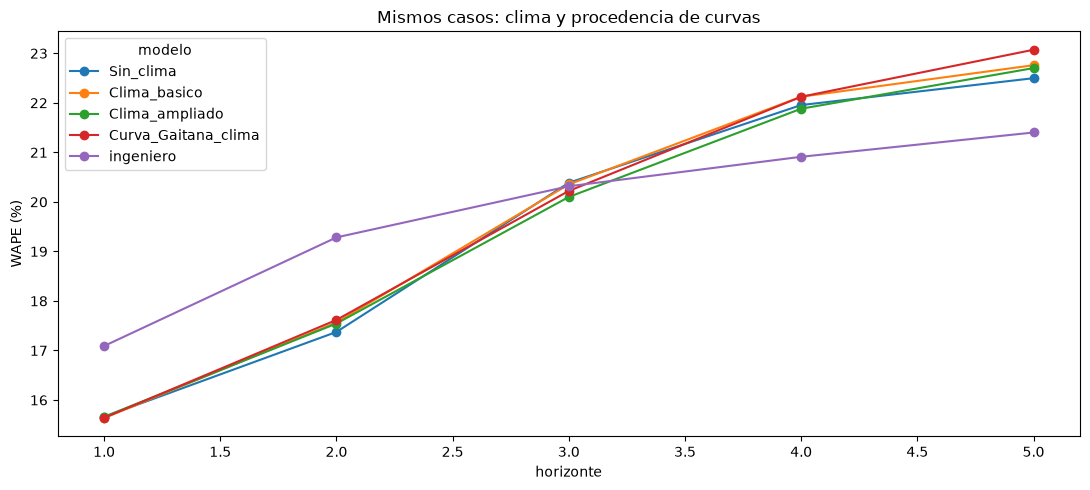

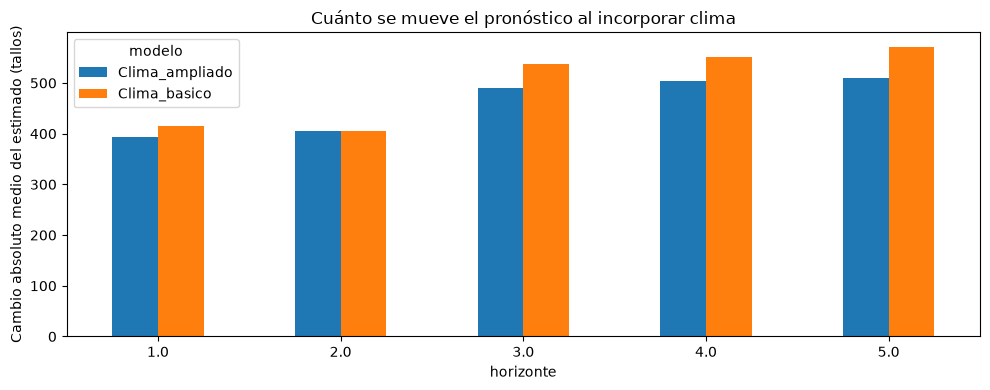

,fase,corte,modelo,split,origen_min,origen_max,objetivo_max,casos_teoria_completa,n,MAE,RMSE,WAPE,sesgo,sesgo_pct
72,evaluacion_2026,2026-08-03,Sin_clima,train,2021-07-05,2026-07-27,2026-07-27,41463,140994,2236.025663,3975.970038,0.224269,-38.476854,-0.385914
73,evaluacion_2026,2026-08-03,Sin_clima,test,2026-08-03,2026-08-31,2026-08-31,157,1758,1670.914368,2956.645098,0.153952,111.300016,1.025480
74,evaluacion_2026,2026-08-03,Clima_basico,train,2021-07-05,2026-07-27,2026-07-27,41463,140994,2193.647527,3891.587632,0.220018,-32.806519,-0.329042
75,evaluacion_2026,2026-08-03,Clima_basico,test,2026-08-03,2026-08-31,2026-08-31,157,1758,1652.288033,2897.978590,0.152236,94.019327,0.866261
76,evaluacion_2026,2026-08-03,Clima_ampliado,train,2021-07-05,2026-07-27,2026-07-27,41463,140994,2183.602538,3864.029299,0.219011,-30.644464,-0.307357
77,evaluacion_2026,2026-08-03,Clima_ampliado,test,2026-08-03,2026-08-31,2026-08-31,157,1758,1665.869067,2902.154831,0.153487,187.471191,1.727294
78,evaluacion_2026,2026-08-03,Curva_Gaitana_clima,train,2021-07-05,2026-07-27,2026-07-27,20036,140994,2226.049860,3952.764207,0.223268,-29.793133,-0.298819
79,evaluacion_2026,2026-08-03,Curva_Gaitana_clima,test,2026-08-03,2026-08-31,2026-08-31,110,1758,1683.414366,2921.353126,0.155104,176.762216,1.628626
108,evaluacion_2026,2026-08-03,Sin_clima,test_principal,2026-08-03,2026-08-31,2026-08-31,126,1560,1809.462685,3122.491568,0.152445,95.639729,0.805755
109,evaluacion_2026,2026-08-03,Clima_basico,test_principal,2026-08-03,2026-08-31,2026-08-31,126,1560,1792.311265,3061.579959,0.151000,86.383169,0.727769


Selección conservada para diario: Sin_clima ; no escoger otro por resultados 2026.


In [6]:
d=pred.loc[pred.grupo_comparacion.eq('principal_estricta_nominal')].copy()
metodos=ETAPAS+['Seleccion_pre2026','Antes_actualizar_clima','ingeniero']
long=d.melt(id_vars=llave+['y','curva_completa','curva_local_completa','teoria_modelo','teoria_local'],value_vars=metodos,var_name='modelo',value_name='prediccion')
def evaluar(g):return pd.Series(metricas(g.y,g.prediccion))
resumen=long.groupby('modelo').apply(evaluar)
porh=long.groupby(['horizonte','modelo']).apply(evaluar)
porproducto=long.groupby(['producto','modelo']).apply(evaluar)
pormes=long.groupby([long.origen.dt.to_period('M').astype(str),'modelo']).apply(evaluar)
mov=[]
for nombre,ref in [('Clima_basico','Sin_clima'),('Clima_ampliado','Clima_basico'),('Curva_Gaitana_clima','Clima_ampliado'),('Clima_basico','Antes_actualizar_clima')]:
    for h,g in d.groupby('horizonte'):
        cambio=g[nombre]-g[ref]
        mov.append({'modelo':nombre,'referencia':ref,'horizonte':h,'casos':len(g),'cambio_medio_tallos':cambio.mean(),'cambio_absoluto_medio':cambio.abs().mean(),'porcentaje_casos_modificados':100*cambio.abs().gt(1e-6).mean(),'mejora_WAPE_pp':100*((g.y-g[ref]).abs().sum()-(g.y-g[nombre]).abs().sum())/g.y.sum()})
mov=pd.DataFrame(mov)
rng=np.random.default_rng(42);ints=[]
for nombre,ref in [('Clima_basico','Sin_clima'),('Clima_ampliado','Clima_basico'),('Curva_Gaitana_clima','Clima_ampliado'),('Seleccion_pre2026','ingeniero')]:
    z=d.assign(ventaja=(d.y-d[ref]).abs()-(d.y-d[nombre]).abs()).groupby('semana_objetivo')[['ventaja','y']].sum()
    ix=rng.integers(0,len(z),(1000,len(z)));v=100*z.ventaja.to_numpy()[ix].sum(axis=1)/z.y.to_numpy()[ix].sum(axis=1)
    ints.append({'modelo':nombre,'referencia':ref,'ventaja_pp':100*z.ventaja.sum()/z.y.sum(),'p025':np.quantile(v,.025),'p975':np.quantile(v,.975)})
intervalos=pd.DataFrame(ints)
display(resumen);display(porh);display(mov);display(intervalos)
d['ruta_curvas']=np.select([d.curva_completa&d.curva_local_completa,d.curva_completa,d.curva_local_completa],['ambas_completas','solo_compartida','solo_local'],default='ninguna_completa')
rutas=[]
for ruta,g in d.groupby('ruta_curvas'):
    for etapa in ETAPAS:rutas.append({'ruta_curvas':ruta,'modelo':etapa}|metricas(g.y,g[etapa]))
rutas=pd.DataFrame(rutas);display(rutas)
inter=d.loc[d.curva_completa&d.curva_local_completa]
teorias=pd.DataFrame([{'modelo':m}|metricas(inter.y,inter[col]) for m,col in [('Teoria_compartida','teoria_modelo'),('Teoria_Gaitana_inferida','teoria_local')]]) if len(inter) else pd.DataFrame()
display(teorias)

FIG=ROOT/'Trabajo escrito/Figuras_resultados'
fig,ax=plt.subplots(figsize=(11,5));porh.WAPE.unstack()[ETAPAS+['ingeniero']].mul(100).plot(ax=ax,marker='o');ax.set_ylabel('WAPE (%)');ax.set_title('Mismos casos: clima y procedencia de curvas');fig.tight_layout();fig.savefig(FIG/'clima_modelos_horizonte.png',dpi=170);plt.show()
fig,ax=plt.subplots(figsize=(10,4));mov.loc[mov.referencia.isin(['Sin_clima','Clima_basico'])].pivot(index='horizonte',columns='modelo',values='cambio_absoluto_medio').plot.bar(ax=ax,rot=0);ax.set_ylabel('Cambio absoluto medio del estimado (tallos)');ax.set_title('Cuánto se mueve el pronóstico al incorporar clima');fig.tight_layout();fig.savefig(FIG/'clima_movimiento_estimado.png',dpi=170);plt.show()
for corte_principal,g in d.groupby('corte'):
    for etapa in ETAPAS:
        flag=g.curva_local_completa if etapa=='Curva_Gaitana_clima' else g.curva_completa
        controles.append({'fase':'evaluacion_2026','corte':corte_principal,'modelo':etapa,'split':'test_principal','origen_min':g.origen.min(),'origen_max':g.origen.max(),'objetivo_max':g.semana_objetivo.max(),'casos_teoria_completa':int(flag.sum())}|metricas(g.y,g[etapa]))
control=pd.DataFrame(controles)
control.to_parquet(OUT/'train_test_clima_por_corte.parquet',index=False)
ultimo=control.loc[control.fase.eq('evaluacion_2026')&control.corte.eq(control.loc[control.fase.eq('evaluacion_2026'),'corte'].max())]
display(ultimo)
with pd.ExcelWriter(OUT/'resultados_clima_curvas.xlsx') as w:
    for nombre,t in [('Resumen',resumen),('Horizonte',porh),('Producto',porproducto),('Mes',pormes),('Validacion_pre2026',tabla_validacion),('Movimiento_estimado',mov),('Incertidumbre',intervalos),('Train_test_por_corte',control),('Ultimo_ajuste',ultimo),('Rutas_curvas',rutas),('Teorias_mismos_casos',teorias)]:t.to_excel(w,sheet_name=nombre)
print('Selección conservada para diario:',elegido,'; no escoger otro por resultados 2026.')


## Resumen final: WAPE y sesgo frente a la versión anterior y al ingeniero

El sesgo mide si el volumen total queda por encima o por debajo del real; WAPE conserva todos los errores absolutos. La mejora de WAPE es anterior menos actual, en puntos porcentuales. La mejora del sesgo absoluto es |sesgo anterior| menos |sesgo actual|, también en puntos. Valores positivos representan mejora, pero ambas métricas pueden moverse en direcciones distintas. No se escoge retrospectivamente un ganador distinto para cada horizonte.

,horizonte,casos,WAPE_anterior_pct,sesgo_anterior_pct,WAPE_actual_pct,sesgo_actual_pct,WAPE_ingeniero_pct,sesgo_ingeniero_pct,mejora_WAPE_vs_anterior_pp,ventaja_WAPE_vs_ingeniero_pp,mejora_sesgo_absoluto_vs_anterior_pp,ventaja_sesgo_absoluto_vs_ingeniero_pp
0,1.0,3413,15.678,-1.713,15.659,-1.234,17.090,-7.563,0.019,1.431,0.479,6.329
1,2.0,3289,17.557,-3.412,17.374,-2.395,19.283,-8.171,0.183,1.909,1.017,5.776
2,3.0,3166,20.389,-3.891,20.386,-2.703,20.315,-9.461,0.003,-0.071,1.188,6.757
3,4.0,3045,22.137,-4.628,21.955,-3.266,20.911,-11.323,0.182,-1.045,1.362,8.057
4,5.0,2925,22.769,-4.235,22.497,-2.633,21.401,-12.633,0.271,-1.096,1.601,9.999
5,Conjunto,15838,19.587,-3.537,19.458,-2.424,19.736,-9.745,0.129,0.277,1.113,7.321


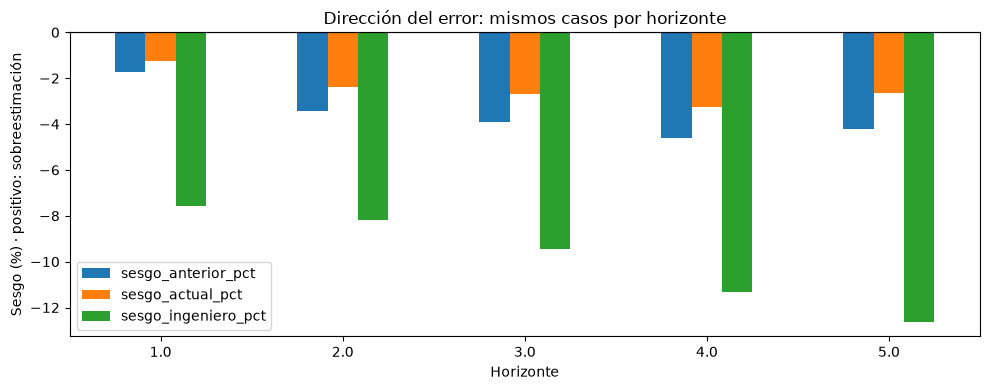

In [7]:
filas=[]
for horizonte,g in list(d.groupby('horizonte'))+[('Conjunto',d)]:
    fila={'horizonte':horizonte,'casos':len(g)}
    for etiqueta,col in [('anterior','Antes_actualizar_clima'),('actual','Seleccion_pre2026'),('ingeniero','ingeniero')]:
        m=metricas(g.y,g[col]);fila['WAPE_'+etiqueta+'_pct']=100*m['WAPE'];fila['sesgo_'+etiqueta+'_pct']=m['sesgo_pct']
    fila['mejora_WAPE_vs_anterior_pp']=fila['WAPE_anterior_pct']-fila['WAPE_actual_pct']
    fila['ventaja_WAPE_vs_ingeniero_pp']=fila['WAPE_ingeniero_pct']-fila['WAPE_actual_pct']
    fila['mejora_sesgo_absoluto_vs_anterior_pp']=abs(fila['sesgo_anterior_pct'])-abs(fila['sesgo_actual_pct'])
    fila['ventaja_sesgo_absoluto_vs_ingeniero_pp']=abs(fila['sesgo_ingeniero_pct'])-abs(fila['sesgo_actual_pct'])
    filas.append(fila)
resumen_final=pd.DataFrame(filas)
display(resumen_final.round(3))
with pd.ExcelWriter(OUT/'resultados_clima_curvas.xlsx',mode='a',engine='openpyxl',if_sheet_exists='replace') as w:
    resumen_final.to_excel(w,sheet_name='WAPE_sesgo_resumen',index=False)
fig,ax=plt.subplots(figsize=(10,4))
resumen_final.iloc[:-1].set_index('horizonte')[['sesgo_anterior_pct','sesgo_actual_pct','sesgo_ingeniero_pct']].plot.bar(ax=ax,rot=0)
ax.axhline(0,color='black',linewidth=.8);ax.set_ylabel('Sesgo (%) · positivo: sobreestimación');ax.set_xlabel('Horizonte');ax.set_title('Dirección del error: mismos casos por horizonte')
fig.tight_layout();fig.savefig(FIG/'clima_sesgo_horizonte.png',dpi=170);plt.show()
